In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
ml_features = pd.read_csv(
    "../data/processed/customer_ml_dataset_v1.csv"
)

print("Dataset loaded successfully.")
print("Shape:", ml_features.shape)

display(ml_features.head())

Dataset loaded successfully.
Shape: (96096, 9)


,customer_unique_id,recency_days,frequency,monetary,total_items,avg_order_value,avg_review_score,total_freight,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1.0,141.90,5.0,12.00,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1.0,27.19,4.0,8.29,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1.0,86.22,3.0,17.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1.0,43.62,4.0,17.63,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1.0,196.89,5.0,16.89,1


In [3]:
print("Columns in dataset:")
print(ml_features.columns.tolist())


Columns in dataset:
['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'total_items', 'avg_order_value', 'avg_review_score', 'total_freight', 'churned']


In [4]:
print("Data types:")
display(ml_features.dtypes)

print("\nMissing values:")
display(ml_features.isnull().sum())

Data types:


customer_unique_id        str
recency_days            int64
frequency               int64
monetary              float64
total_items           float64
avg_order_value       float64
avg_review_score      float64
total_freight         float64
churned                 int64
dtype: object


Missing values:


customer_unique_id    0
recency_days          0
frequency             0
monetary              0
total_items           0
avg_order_value       1
avg_review_score      0
total_freight         0
churned               0
dtype: int64

In [5]:
print("Churn distribution:")
display(ml_features["churned"].value_counts())

print("\nChurn percentage:")
display(
    ml_features["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn distribution:


churned
1    86432
0     9664
Name: count, dtype: int64


Churn percentage:


churned
1    89.94
0    10.06
Name: proportion, dtype: float64

In [6]:


X = ml_features.drop(
    columns=["customer_unique_id", "churned"]
)

y = ml_features["churned"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (96096, 7)
Target (y): (96096,)


In [7]:
print("Features used for ML:")
print(X.columns.tolist())

Features used for ML:
['recency_days', 'frequency', 'monetary', 'total_items', 'avg_order_value', 'avg_review_score', 'total_freight']


In [8]:
print("Non-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

Non-numeric columns:
[]


In [9]:
orders = pd.read_csv(
    "../data/processed/clean_orders.csv",
    parse_dates=["order_purchase_timestamp"]
)

print("Orders loaded:", orders.shape)
display(orders.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/clean_orders.csv'

In [10]:
import os

print(os.listdir("../data/processed"))

['business_action_summary.csv', 'business_kpis.csv', 'category_analysis.csv', 'clean_orders_final.csv', 'clean_orders_stage1.csv', 'clean_orders_stage2.csv', 'clean_orders_stage3.csv', 'clean_orders_stage4.csv', 'clean_orders_stage5.csv', 'clean_orders_stage6.csv', 'customer_decision_segments.csv', 'customer_ml_dataset_v1.csv', 'customer_ml_features_v1.csv', 'customer_orders.csv', 'customer_retention_base.csv', 'customer_rfm_base.csv', 'customer_segments.csv', 'customer_summary.csv', 'customer_summary_recency.csv', 'customer_summary_rfm_base.csv', 'monthly_revenue_analysis.csv', 'order_level_dataset.csv', 'segment_business_value.csv']


In [11]:
order_files = [
    f for f in os.listdir("../data/processed")
    if "order" in f.lower()
]

print(order_files)

['clean_orders_final.csv', 'clean_orders_stage1.csv', 'clean_orders_stage2.csv', 'clean_orders_stage3.csv', 'clean_orders_stage4.csv', 'clean_orders_stage5.csv', 'clean_orders_stage6.csv', 'customer_orders.csv', 'order_level_dataset.csv']


In [12]:
orders = pd.read_csv(
    "../data/processed/customer_orders.csv"
)

print("Shape:", orders.shape)
print("Columns:")
print(orders.columns.tolist())

display(orders.head())

Shape: (99441, 11)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [13]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state']


In [14]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

print("Missing dates:", orders["order_purchase_timestamp"].isna().sum())
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

Missing dates: 0
First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [15]:
max_date = orders["order_purchase_timestamp"].max()

prediction_start = max_date - pd.Timedelta(days=90)

print("Prediction period starts:", prediction_start)
print("Dataset end:", max_date)

Prediction period starts: 2018-07-19 17:30:18
Dataset end: 2018-10-17 17:30:18


In [16]:
historical_orders = orders[
    orders["order_purchase_timestamp"] < prediction_start
].copy()

print("Historical orders:", historical_orders.shape)
print(
    "Historical period:",
    historical_orders["order_purchase_timestamp"].min(),
    "to",
    historical_orders["order_purchase_timestamp"].max()
)

Historical orders: (89912, 11)
Historical period: 2016-09-04 21:15:19 to 2018-07-19 17:24:35


In [22]:
customer_history = (
    historical_orders
    .groupby("customer_unique_id")
    .agg(
        historical_orders=("order_id", "nunique"),
        last_purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

display(customer_history.head())

,customer_unique_id,historical_orders,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42


In [23]:
customer_history["historical_recency_days"] = (
    prediction_start - customer_history["last_purchase"]
).dt.days

display(
    customer_history[
        [
            "customer_unique_id",
            "historical_orders",
            "last_purchase",
            "historical_recency_days"
        ]
    ].head()
)

,customer_unique_id,historical_orders,last_purchase,historical_recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,70
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,73
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,495
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,279
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,246


In [19]:
print("Orders columns:")
for i, col in enumerate(orders.columns):
    print(i, ":", col)

Orders columns:
0 : order_id
1 : customer_id
2 : order_status
3 : order_purchase_timestamp
4 : order_approved_at
5 : order_delivered_carrier_date
6 : order_delivered_customer_date
7 : order_estimated_delivery_date
8 : customer_unique_id
9 : customer_city
10 : customer_state


In [20]:
print("\nFirst 5 rows:")
display(orders.head())


First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [21]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state']


In [24]:
print("Customers available for ML:", len(customer_history))

print(
    "Recency statistics:"
)

display(
    customer_history["historical_recency_days"]
    .describe()
)

Customers available for ML: 86924
Recency statistics:


count    86924.00000
mean       221.12129
std        142.94833
min          0.00000
25%        104.00000
50%        199.00000
75%        324.00000
max        682.00000
Name: historical_recency_days, dtype: float64

In [25]:
future_orders = orders[
    orders["order_purchase_timestamp"] >= prediction_start
].copy()

print("Future orders:", future_orders.shape)

print(
    "Future period:",
    future_orders["order_purchase_timestamp"].min(),
    "to",
    future_orders["order_purchase_timestamp"].max()
)

Future orders: (9529, 11)
Future period: 2018-07-19 17:31:45 to 2018-10-17 17:30:18


In [26]:
future_activity = (
    future_orders
    .groupby("customer_unique_id")
    .agg(
        future_orders=("order_id", "nunique")
    )
    .reset_index()
)

display(future_activity.head())

,customer_unique_id,future_orders
0,000ec5bff359e1c0ad76a81a45cb598f,1
1,000fbf0473c10fc1ab6f8d2d286ce20c,1
2,0015752e079902b12cd00b9b7596276b,1
3,00172711b30d52eea8b313a7f2cced02,2
4,001928b561575b2821c92254a2327d06,1


In [27]:
model_data = customer_history.merge(
    future_activity,
    on="customer_unique_id",
    how="left"
)

model_data["future_orders"] = (
    model_data["future_orders"]
    .fillna(0)
)

model_data["churned"] = (
    model_data["future_orders"] == 0
).astype(int)

display(model_data.head())

,customer_unique_id,historical_orders,last_purchase,historical_recency_days,future_orders,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,70,0.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,73,0.0,1
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,495,0.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,279,0.0,1
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,246,0.0,1


In [28]:
print(model_data["churned"].value_counts())
print()
print(
    model_data["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churned
1    86684
0      240
Name: count, dtype: int64

churned
1    99.72
0     0.28
Name: proportion, dtype: float64


In [29]:
model_data["orders_per_month"] = (
    model_data["historical_orders"] /
    (model_data["historical_recency_days"] / 30 + 1)
)

model_data["avg_days_between_orders"] = (
    model_data["historical_recency_days"] /
    model_data["historical_orders"].clip(lower=1)
)

display(model_data.head())

,customer_unique_id,historical_orders,last_purchase,historical_recency_days,future_orders,churned,orders_per_month,avg_days_between_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,70,0.0,1,0.300000,70.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,73,0.0,1,0.291262,73.0
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,495,0.0,1,0.057143,495.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,279,0.0,1,0.097087,279.0
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,246,0.0,1,0.108696,246.0


In [30]:
feature_columns = [
    "historical_orders",
    "historical_recency_days",
    "orders_per_month",
    "avg_days_between_orders"
]

X = model_data[feature_columns]
y = model_data["churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (86924, 4)
y shape: (86924,)


,historical_orders,historical_recency_days,orders_per_month,avg_days_between_orders
0,1,70,0.300000,70.0
1,1,73,0.291262,73.0
2,1,495,0.057143,495.0
3,1,279,0.097087,279.0
4,1,246,0.108696,246.0


In [31]:
print("Missing values:")
display(X.isnull().sum())

print(
    "\nInfinite values:",
    np.isinf(X).sum().sum()
)

print(
    "\nTarget distribution:"
)

display(y.value_counts())

Missing values:


historical_orders          0
historical_recency_days    0
orders_per_month           0
avg_days_between_orders    0
dtype: int64


Infinite values: 0

Target distribution:


churned
1    86684
0      240
Name: count, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (69539, 4)
Testing data: (17385, 4)


In [33]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
churned
1    0.997
0    0.003
Name: proportion, dtype: float64

Testing target distribution:
churned
1    0.997
0    0.003
Name: proportion, dtype: float64


In [34]:
print("X_train:")
display(X_train.head())

print("y_train:")
display(y_train.head())

print("\nX_test:")
display(X_test.head())

print("y_test:")
display(y_test.head())

X_train:


,historical_orders,historical_recency_days,orders_per_month,avg_days_between_orders
72694,1,103,0.225564,103.0
3488,1,77,0.280374,77.0
75444,1,336,0.081967,336.0
495,1,155,0.162162,155.0
29877,1,289,0.094044,289.0


y_train:


72694    1
3488     1
75444    1
495      1
29877    1
Name: churned, dtype: int64


X_test:


,historical_orders,historical_recency_days,orders_per_month,avg_days_between_orders
84671,1,334,0.082418,334.0
39870,1,143,0.173410,143.0
45050,1,236,0.112782,236.0
76578,1,245,0.109091,245.0
35753,1,323,0.084986,323.0


y_test:


84671    1
39870    1
45050    1
76578    1
35753    1
Name: churned, dtype: int64

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [36]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred_lr[:10])
print("First 10 probabilities:", y_prob_lr[:10])

Predictions generated successfully.
First 10 predictions: [1 1 1 1 1 1 1 1 1 1]
First 10 probabilities: [0.99811929 0.99733412 0.9977869  0.99782169 0.99808622 0.99806471
 0.99863598 0.99667629 0.9977869  0.99776309]


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("========== LOGISTIC REGRESSION ==========")

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_lr), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_lr, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_lr, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_lr, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_lr), 4
))

========== LOGISTIC REGRESSION ==========
Accuracy : 0.9972
Precision: 0.9972
Recall   : 1.0
F1 Score : 0.9986
ROC-AUC  : 0.6306


Confusion Matrix:
[[    0    48]
 [    0 17337]]


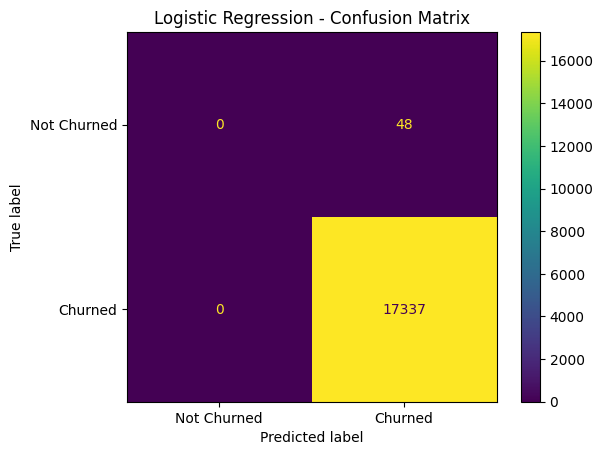

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

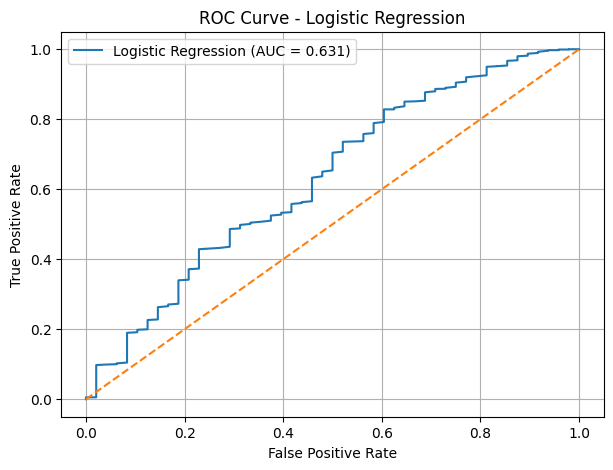

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [41]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated.
First 10 predictions: [1 1 1 1 1 1 1 1 1 1]


In [42]:
print("========== RANDOM FOREST ==========")

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_rf), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_rf, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_rf, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_rf, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_rf), 4
))

========== RANDOM FOREST ==========
Accuracy : 0.7761
Precision: 0.9978
Recall   : 0.7772
F1 Score : 0.8738
ROC-AUC  : 0.5388


In [43]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9972,0.9972,1.0000,0.9986,0.6306
1,Random Forest,0.7761,0.9978,0.7772,0.8738,0.5388


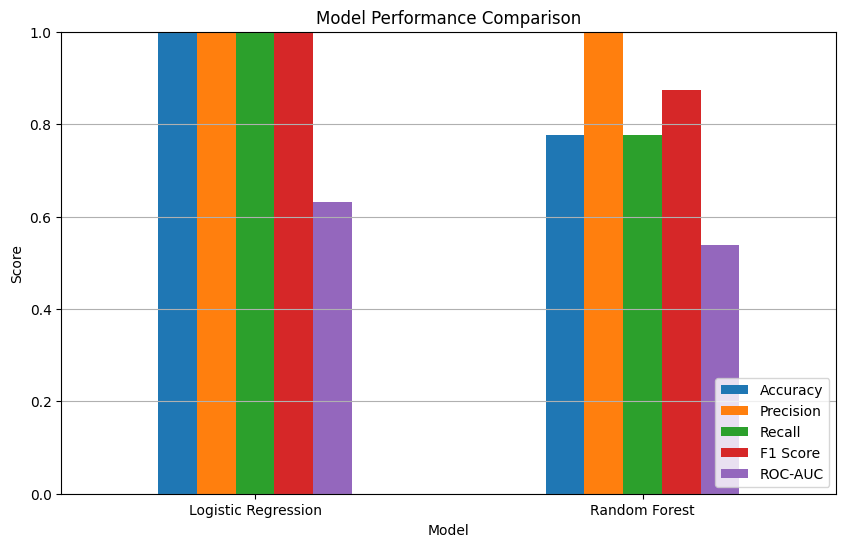

In [44]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [45]:
best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

best_auc = results["ROC-AUC"].max()

print("Best model:", best_model_name)
print("Best ROC-AUC:", round(best_auc, 4))

Best model: Logistic Regression
Best ROC-AUC: 0.6306


In [46]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,orders_per_month,0.358129
3,avg_days_between_orders,0.319528
1,historical_recency_days,0.290616
0,historical_orders,0.031727


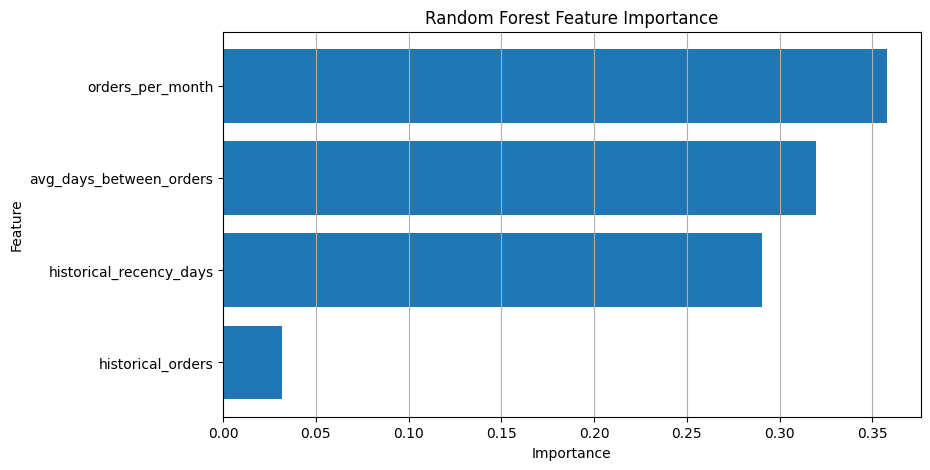

In [47]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [48]:
top_feature = feature_importance.iloc[0]

print("Most important feature:", top_feature["Feature"])
print("Importance:", round(top_feature["Importance"], 4))

Most important feature: orders_per_month
Importance: 0.3581


In [50]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:")
print(np.round(cv_scores, 4))

print("\nMean ROC-AUC:", round(cv_scores.mean(), 4))
print("Std deviation:", round(cv_scores.std(), 4))

Cross-validation ROC-AUC scores:
[0.4812 0.5681 0.5441 0.5806 0.561 ]

Mean ROC-AUC: 0.547
Std deviation: 0.0349


In [51]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:")
print(np.round(cv_scores, 4))

print("\nMean ROC-AUC:", round(cv_scores.mean(), 4))
print("Std deviation:", round(cv_scores.std(), 4))

Cross-validation ROC-AUC scores:
[0.4812 0.5681 0.5441 0.5806 0.561 ]

Mean ROC-AUC: 0.547
Std deviation: 0.0349


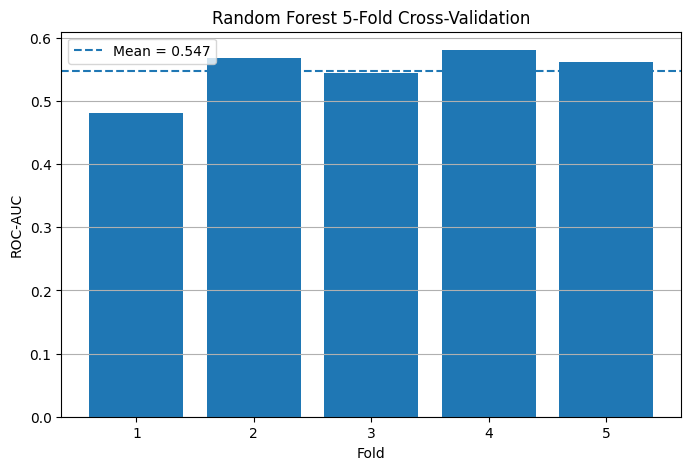

In [52]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 6),
    cv_scores
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("Random Forest 5-Fold Cross-Validation")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(axis="y")

plt.show()

In [53]:
if cv_scores.std() < 0.03:
    print("Model performance is relatively stable across folds.")
else:
    print("Model performance varies across folds; further tuning may help.")

Model performance varies across folds; further tuning may help.


In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [59]:
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")
print("Best parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV ROC-AUC:",
    round(grid_search.best_score_, 4)
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Hyperparameter tuning completed.
Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV ROC-AUC: 0.5904


In [57]:
best_rf_model = grid_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [61]:
y_pred_tuned = best_rf_model.predict(X_test)
y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [62]:
tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

print("========== TUNED RANDOM FOREST ==========")

for metric, score in tuned_results.items():
    print(f"{metric}: {score:.4f}")

========== TUNED RANDOM FOREST ==========
Accuracy: 0.7744
Precision: 0.9978
Recall: 0.7755
F1 Score: 0.8727
ROC-AUC: 0.5639


In [63]:
tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned)
}

print("========== TUNED RANDOM FOREST ==========")

for metric, score in tuned_results.items():
    print(f"{metric}: {score:.4f}")

========== TUNED RANDOM FOREST ==========
Accuracy: 0.7744
Precision: 0.9978
Recall: 0.7755
F1 Score: 0.8727
ROC-AUC: 0.5639


In [64]:
customer_history["customer_lifetime_days"] = (
    prediction_start - historical_orders
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .transform("min")
).dt.days

customer_history["customer_lifetime_days"] = (
    customer_history["customer_lifetime_days"].clip(lower=1)
)

customer_history["orders_per_lifetime_month"] = (
    customer_history["historical_orders"] /
    (customer_history["customer_lifetime_days"] / 30)
)

display(customer_history.head())

,customer_unique_id,historical_orders,last_purchase,historical_recency_days,customer_lifetime_days,orders_per_lifetime_month
0,0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,70,318.0,0.094340
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,73,NaN,NaN
2,0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,495,NaN,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,279,242.0,0.123967
4,0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,246,155.0,0.193548


In [65]:

new_features = [
    "historical_orders",
    "historical_recency_days",
    "customer_lifetime_days",
    "orders_per_lifetime_month"
]

display(customer_history[new_features].describe())


,historical_orders,historical_recency_days,customer_lifetime_days,orders_per_lifetime_month
count,86924.000000,86924.00000,78566.000000,78566.000000
mean,1.034375,221.12129,225.985350,0.561809
std,0.210656,142.94833,143.681016,2.659965
min,1.000000,0.00000,1.000000,0.043988
25%,1.000000,104.00000,108.000000,0.092025
50%,1.000000,199.00000,210.000000,0.149254
75%,1.000000,324.00000,332.000000,0.285714
max,13.000000,682.00000,682.000000,60.000000


In [66]:
feature_columns_v2 = [
    "historical_orders",
    "historical_recency_days",
    "orders_per_month",
    "avg_days_between_orders",
    "customer_lifetime_days",
    "orders_per_lifetime_month"
]

# Combine the new features with the churn target
model_data_v2 = model_data[
    ["customer_unique_id", "churned"]
].merge(
    customer_history[
        ["customer_unique_id"] + [
            "historical_orders",
            "historical_recency_days",
            "customer_lifetime_days",
            "orders_per_lifetime_month"
        ]
    ],
    on="customer_unique_id",
    how="inner"
)

# Recreate the two features that were already in model_data
model_data_v2["orders_per_month"] = (
    model_data_v2["historical_orders"] /
    (model_data_v2["historical_recency_days"] / 30 + 1)
)

model_data_v2["avg_days_between_orders"] = (
    model_data_v2["historical_recency_days"] /
    model_data_v2["historical_orders"].clip(lower=1)
)

display(model_data_v2.head())

,customer_unique_id,churned,historical_orders,historical_recency_days,customer_lifetime_days,orders_per_lifetime_month,orders_per_month,avg_days_between_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,70,318.0,0.094340,0.300000,70.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,73,NaN,NaN,0.291262,73.0
2,0000f46a3911fa3c0805444483337064,1,1,495,NaN,NaN,0.057143,495.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,279,242.0,0.123967,0.097087,279.0
4,0004aac84e0df4da2b147fca70cf8255,1,1,246,155.0,0.193548,0.108696,246.0


In [67]:
X_v2 = model_data_v2[feature_columns_v2]
y_v2 = model_data_v2["churned"]

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

display(X_v2.head())

X_v2 shape: (86924, 6)
y_v2 shape: (86924,)


,historical_orders,historical_recency_days,orders_per_month,avg_days_between_orders,customer_lifetime_days,orders_per_lifetime_month
0,1,70,0.300000,70.0,318.0,0.094340
1,1,73,0.291262,73.0,NaN,NaN
2,1,495,0.057143,495.0,NaN,NaN
3,1,279,0.097087,279.0,242.0,0.123967
4,1,246,0.108696,246.0,155.0,0.193548


In [68]:
print("Missing values:")
display(X_v2.isnull().sum())

print("\nInfinite values:", np.isinf(X_v2).sum().sum())

print("\nTarget distribution:")
display(y_v2.value_counts())

Missing values:


historical_orders               0
historical_recency_days         0
orders_per_month                0
avg_days_between_orders         0
customer_lifetime_days       8358
orders_per_lifetime_month    8358
dtype: int64


Infinite values: 0

Target distribution:


churned
1    86684
0      240
Name: count, dtype: int64

In [69]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

print("Training data:", X_train_v2.shape)
print("Testing data:", X_test_v2.shape)

Training data: (69539, 6)
Testing data: (17385, 6)


In [70]:
print("Training target:")
print(y_train_v2.value_counts(normalize=True).round(3))

print("\nTesting target:")
print(y_test_v2.value_counts(normalize=True).round(3))

Training target:
churned
1    0.997
0    0.003
Name: proportion, dtype: float64

Testing target:
churned
1    0.997
0    0.003
Name: proportion, dtype: float64


In [71]:
print("Features used in improved model:")
print(X_v2.columns.tolist())

print("\nMissing values:")
print(X_v2.isnull().sum().sum())

print("Infinite values:", np.isinf(X_v2).sum().sum())

Features used in improved model:
['historical_orders', 'historical_recency_days', 'orders_per_month', 'avg_days_between_orders', 'customer_lifetime_days', 'orders_per_lifetime_month']

Missing values:
16716
Infinite values: 0


In [72]:
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(X_train_v2, y_train_v2)

print("Improved Random Forest trained successfully.")

Improved Random Forest trained successfully.


In [73]:
y_pred_v2 = rf_model_v2.predict(X_test_v2)
y_prob_v2 = rf_model_v2.predict_proba(X_test_v2)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [74]:
print("========== IMPROVED RANDOM FOREST ==========")

print("Accuracy :", round(
    accuracy_score(y_test_v2, y_pred_v2), 4
))

print("Precision:", round(
    precision_score(y_test_v2, y_pred_v2, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test_v2, y_pred_v2, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test_v2, y_pred_v2, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test_v2, y_prob_v2), 4
))

========== IMPROVED RANDOM FOREST ==========
Accuracy : 0.8793
Precision: 0.9974
Recall   : 0.8812
F1 Score : 0.9357
ROC-AUC  : 0.5097


In [75]:
print("Actual target distribution:")
print(y_test_v2.value_counts())

print("\nPredicted target distribution:")
print(pd.Series(y_pred_v2).value_counts())

print("\nPrediction probabilities:")
print(pd.Series(y_prob_v2).describe())

Actual target distribution:
churned
1    17337
0       48
Name: count, dtype: int64

Predicted target distribution:
1    15318
0     2067
Name: count, dtype: int64

Prediction probabilities:
count    17385.000000
mean         0.721625
std          0.177361
min          0.043800
25%          0.594496
50%          0.726406
75%          0.871769
max          1.000000
dtype: float64


In [76]:
print("ROC-AUC:", roc_auc_score(y_test_v2, y_prob_v2))

print("\nProbability by actual class:")

display(
    pd.DataFrame({
        "actual": y_test_v2.values,
        "probability": y_prob_v2
    }).groupby("actual")["probability"].describe()
)

ROC-AUC: 0.5096512035915479

Probability by actual class:


,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,48.0,0.705699,0.217191,0.187836,0.545832,0.720243,0.881859,0.998446
1,17337.0,0.721669,0.177244,0.043800,0.594649,0.726406,0.871769,1.000000


In [77]:
print(
    model_data_v2.groupby("churned")[feature_columns_v2]
    .mean()
    .round(2)
)

         historical_orders  historical_recency_days  orders_per_month  \
churned                                                                 
0                     1.20                   171.55              0.35   
1                     1.03                   221.26              0.20   

         avg_days_between_orders  customer_lifetime_days  \
churned                                                    
0                         162.77                  226.64   
1                         218.05                  225.98   

         orders_per_lifetime_month  
churned                             
0                             0.71  
1                             0.56  


In [78]:
prediction_start_180 = max_date - pd.Timedelta(days=180)

print("180-day prediction period starts:", prediction_start_180)
print("Dataset end:", max_date)

180-day prediction period starts: 2018-04-20 17:30:18
Dataset end: 2018-10-17 17:30:18


In [79]:
historical_orders_180 = orders[
    orders["order_purchase_timestamp"] < prediction_start_180
].copy()

future_orders_180 = orders[
    orders["order_purchase_timestamp"] >= prediction_start_180
].copy()

print("Historical orders:", historical_orders_180.shape)
print("Future orders:", future_orders_180.shape)

Historical orders: (71257, 11)
Future orders: (28184, 11)


In [80]:
future_customers_180 = set(
    future_orders_180["customer_unique_id"]
)

historical_customers_180 = set(
    historical_orders_180["customer_unique_id"]
)

churn_check = pd.Series(
    list(historical_customers_180)
).isin(future_customers_180)

print("Historical customers:", len(historical_customers_180))
print("Customers with future purchase:", churn_check.sum())
print("Customers without future purchase:", (~churn_check).sum())

Historical customers: 68940
Customers with future purchase: 588
Customers without future purchase: 68352


In [81]:
customer_last_purchase = (
    orders
    .groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

display(customer_last_purchase.head())

,customer_unique_id,last_purchase,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1


In [82]:
customer_last_purchase["days_since_purchase"] = (
    max_date - customer_last_purchase["last_purchase"]
).dt.days

display(
    customer_last_purchase[
        [
            "customer_unique_id",
            "last_purchase",
            "total_orders",
            "days_since_purchase"
        ]
    ].head()
)

,customer_unique_id,last_purchase,total_orders,days_since_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,336


In [83]:
customer_last_purchase["churned"] = (
    customer_last_purchase["days_since_purchase"] >= 180
).astype(int)

print("New churn target:")
print(customer_last_purchase["churned"].value_counts())

print("\nPercentages:")
print(
    customer_last_purchase["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

New churn target:
churned
1    68352
0    27744
Name: count, dtype: int64

Percentages:
churned
1    71.13
0    28.87
Name: proportion, dtype: float64


In [84]:
final_data = customer_last_purchase.copy()

final_data["customer_lifetime_days"] = (
    final_data["last_purchase"]
    - orders.groupby("customer_unique_id")["order_purchase_timestamp"]
      .transform("min")
).dt.days

In [85]:
first_purchase = (
    orders.groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
    .rename(columns={"order_purchase_timestamp": "first_purchase"})
)

final_data = customer_last_purchase.merge(
    first_purchase,
    on="customer_unique_id",
    how="left"
)

final_data["customer_lifetime_days"] = (
    final_data["last_purchase"] - final_data["first_purchase"]
).dt.days

final_data["customer_lifetime_days"] = (
    final_data["customer_lifetime_days"].fillna(0)
)

display(final_data.head())

,customer_unique_id,last_purchase,total_orders,days_since_purchase,churned,first_purchase,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,160,0,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,163,0,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,585,1,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,369,1,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,336,1,2017-11-14 19:45:42,0


In [86]:
final_data["orders_per_month"] = (
    final_data["total_orders"] /
    (final_data["customer_lifetime_days"] / 30 + 1)
)

final_data["orders_per_lifetime_month"] = (
    final_data["total_orders"] /
    (final_data["customer_lifetime_days"] / 30 + 1)
)

display(
    final_data[
        [
            "customer_unique_id",
            "total_orders",
            "customer_lifetime_days",
            "orders_per_month",
            "orders_per_lifetime_month",
            "churned"
        ]
    ].head()
)

,customer_unique_id,total_orders,customer_lifetime_days,orders_per_month,orders_per_lifetime_month,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,0,1.0,1.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,0,1.0,1.0,0
2,0000f46a3911fa3c0805444483337064,1,0,1.0,1.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,0,1.0,1.0,1
4,0004aac84e0df4da2b147fca70cf8255,1,0,1.0,1.0,1


In [87]:
final_features = [
    "total_orders",
    "customer_lifetime_days",
    "orders_per_month",
    "orders_per_lifetime_month"
]

X_final = final_data[final_features]
y_final = final_data["churned"]

print("Features:")
print(final_features)

print("\nX shape:", X_final.shape)
print("y shape:", y_final.shape)

Features:
['total_orders', 'customer_lifetime_days', 'orders_per_month', 'orders_per_lifetime_month']

X shape: (96096, 4)
y shape: (96096,)


In [88]:
print("Missing values:")
display(X_final.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X_final).sum().sum())

Missing values:


total_orders                 0
customer_lifetime_days       0
orders_per_month             0
orders_per_lifetime_month    0
dtype: int64


Infinite values:
0


In [89]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

print("Training:", X_train_final.shape)
print("Testing :", X_test_final.shape)

Training: (76876, 4)
Testing : (19220, 4)


In [90]:
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train_final, y_train_final)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


In [91]:
y_pred_final = final_rf_model.predict(X_test_final)
y_prob_final = final_rf_model.predict_proba(X_test_final)[:, 1]

print("Final predictions generated successfully.")

Final predictions generated successfully.


In [92]:
print("========== FINAL RANDOM FOREST ==========")

print("Accuracy :", round(
    accuracy_score(y_test_final, y_pred_final), 4
))

print("Precision:", round(
    precision_score(y_test_final, y_pred_final, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test_final, y_pred_final, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test_final, y_pred_final, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test_final, y_prob_final), 4
))

========== FINAL RANDOM FOREST ==========
Accuracy : 0.7079
Precision: 0.7134
Recall   : 0.9852
F1 Score : 0.8275
ROC-AUC  : 0.5071


In [93]:
print("Available datasets:")

for name in [
    "customers",
    "orders",
    "order_items",
    "payments",
    "reviews",
    "products",
    "sellers"
]:
    if name in globals():
        print(f"✓ {name}: {globals()[name].shape}")
    else:
        print(f"✗ {name}: not loaded")

Available datasets:
✗ customers: not loaded
✓ orders: (99441, 11)
✗ order_items: not loaded
✗ payments: not loaded
✗ reviews: not loaded
✗ products: not loaded
✗ sellers: not loaded


In [94]:
print("\nOrders columns:")
print(orders.columns.tolist())


Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state']


In [95]:
if "payments" in globals():
    print("\nPayments columns:")
    print(payments.columns.tolist())

if "order_items" in globals():
    print("\nOrder items columns:")
    print(order_items.columns.tolist())

if "reviews" in globals():
    print("\nReviews columns:")
    print(reviews.columns.tolist())

In [96]:
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

print("Payments:", payments.shape)
display(payments.head())

Payments: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [97]:
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

print("Order items:", order_items.shape)
display(order_items.head())

Order items: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [98]:
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("Reviews:", reviews.shape)
display(reviews.head())

Reviews: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [99]:
print("PAYMENTS")
print(payments.columns.tolist())
print(payments.shape)

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
(103886, 5)


In [100]:
print("ORDER ITEMS")
print(order_items.columns.tolist())
print(order_items.shape)

ORDER ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
(112650, 7)


In [101]:
print("REVIEWS")
print(reviews.columns.tolist())
print(reviews.shape)

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
(99224, 7)


In [102]:
payment_features = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_methods=("payment_type", "nunique")
    )
    .reset_index()
)

display(payment_features.head())

,order_id,payment_value,payment_installments,payment_methods
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [103]:
customer_payment_features = (
    orders[
        ["order_id", "customer_unique_id"]
    ]
    .merge(
        payment_features,
        on="order_id",
        how="left"
    )
    .groupby("customer_unique_id")
    .agg(
        total_spend=("payment_value", "sum"),
        avg_order_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean"),
        payment_methods_used=("payment_methods", "sum")
    )
    .reset_index()
)

display(customer_payment_features.head())

,customer_unique_id,total_spend,avg_order_value,avg_installments,payment_methods_used
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,141.90,8.0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,27.19,1.0,1.0
2,0000f46a3911fa3c0805444483337064,86.22,86.22,8.0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,43.62,4.0,1.0
4,0004aac84e0df4da2b147fca70cf8255,196.89,196.89,6.0,1.0


In [104]:
print("Customer payment features:", customer_payment_features.shape)

print("\nMissing values:")
display(customer_payment_features.isnull().sum())

print("\nSummary:")
display(
    customer_payment_features[
        [
            "total_spend",
            "avg_order_value",
            "avg_installments",
            "payment_methods_used"
        ]
    ].describe()
)

Customer payment features: (96096, 5)

Missing values:


customer_unique_id      0
total_spend             0
avg_order_value         1
avg_installments        1
payment_methods_used    0
dtype: int64


Summary:


,total_spend,avg_order_value,avg_installments,payment_methods_used
count,96096.000000,96095.000000,96095.000000,96096.000000
mean,166.592492,161.401796,2.917450,1.058171
std,231.428332,222.308078,2.693102,0.269025
min,0.000000,0.000000,0.000000,0.000000
25%,63.120000,62.460000,1.000000,1.000000
50%,108.000000,105.830000,2.000000,1.000000
75%,183.530000,177.210000,4.000000,1.000000
max,13664.080000,13664.080000,24.000000,17.000000


In [105]:
item_features = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        product_count=("product_id", "nunique"),
        seller_count=("seller_id", "nunique"),
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

display(item_features.head())

,order_id,item_count,product_count,seller_count,item_value,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


In [106]:
customer_item_features = (
    orders[
        ["order_id", "customer_unique_id"]
    ]
    .merge(
        item_features,
        on="order_id",
        how="left"
    )
    .groupby("customer_unique_id")
    .agg(
        total_items=("item_count", "sum"),
        unique_products=("product_count", "sum"),
        unique_sellers=("seller_count", "sum"),
        total_item_value=("item_value", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
)

display(customer_item_features.head())

,customer_unique_id,total_items,unique_products,unique_sellers,total_item_value,total_freight
0,0000366f3b9a7992bf8c76cfdf3221e2,1.0,1.0,1.0,129.90,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.0,1.0,1.0,18.90,8.29
2,0000f46a3911fa3c0805444483337064,1.0,1.0,1.0,69.00,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,1.0,1.0,1.0,25.99,17.63
4,0004aac84e0df4da2b147fca70cf8255,1.0,1.0,1.0,180.00,16.89


In [107]:
print("Customer item features:", customer_item_features.shape)

display(
    customer_item_features[
        [
            "total_items",
            "unique_products",
            "unique_sellers",
            "total_item_value",
            "total_freight"
        ]
    ].describe()
)

Customer item features: (96096, 6)


,total_items,unique_products,unique_sellers,total_item_value,total_freight
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,1.172265,1.065861,1.040730,141.438184,23.433957
std,0.627071,0.339595,0.265045,217.215904,22.883215
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,45.990000,13.920000
50%,1.000000,1.000000,1.000000,89.000000,17.530000
75%,1.000000,1.000000,1.000000,154.000000,25.420000
max,24.000000,16.000000,16.000000,13440.000000,1794.960000


In [108]:
review_features = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
    .reset_index()
)

display(review_features.head())

,order_id,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [109]:
customer_review_features = (
    orders[
        ["order_id", "customer_unique_id"]
    ]
    .merge(
        review_features,
        on="order_id",
        how="left"
    )
    .groupby("customer_unique_id")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_count", "sum")
    )
    .reset_index()
)

display(customer_review_features.head())

,customer_unique_id,avg_review_score,total_reviews
0,0000366f3b9a7992bf8c76cfdf3221e2,5.0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4.0,1.0
2,0000f46a3911fa3c0805444483337064,3.0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,4.0,1.0
4,0004aac84e0df4da2b147fca70cf8255,5.0,1.0


In [110]:
print("Customer review features:", customer_review_features.shape)

display(
    customer_review_features[
        [
            "avg_review_score",
            "total_reviews"
        ]
    ].describe()
)

Customer review features: (96096, 3)


,avg_review_score,total_reviews
count,95380.000000,96096.000000
mean,4.084963,1.032551
std,1.341661,0.269283
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,17.000000


In [111]:
customer_features = (
    customer_last_purchase[
        [
            "customer_unique_id",
            "total_orders",
            "days_since_purchase",
            "churned"
        ]
    ]
    .merge(
        customer_payment_features,
        on="customer_unique_id",
        how="left"
    )
    .merge(
        customer_item_features,
        on="customer_unique_id",
        how="left"
    )
    .merge(
        customer_review_features,
        on="customer_unique_id",
        how="left"
    )
)

print("Customer feature dataset:", customer_features.shape)

display(customer_features.head())

Customer feature dataset: (96096, 15)


,customer_unique_id,total_orders,days_since_purchase,churned,total_spend,avg_order_value,avg_installments,payment_methods_used,total_items,unique_products,unique_sellers,total_item_value,total_freight,avg_review_score,total_reviews
0,0000366f3b9a7992bf8c76cfdf3221e2,1,160,0,141.90,141.90,8.0,1.0,1.0,1.0,1.0,129.90,12.00,5.0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,163,0,27.19,27.19,1.0,1.0,1.0,1.0,1.0,18.90,8.29,4.0,1.0
2,0000f46a3911fa3c0805444483337064,1,585,1,86.22,86.22,8.0,1.0,1.0,1.0,1.0,69.00,17.22,3.0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,369,1,43.62,43.62,4.0,1.0,1.0,1.0,1.0,25.99,17.63,4.0,1.0
4,0004aac84e0df4da2b147fca70cf8255,1,336,1,196.89,196.89,6.0,1.0,1.0,1.0,1.0,180.00,16.89,5.0,1.0


In [112]:
numeric_features = customer_features.select_dtypes(
    include="number"
).columns

customer_features[numeric_features] = (
    customer_features[numeric_features]
    .fillna(0)
)

print("Missing values remaining:")
print(customer_features.isnull().sum().sum())

Missing values remaining:
0


In [113]:
print("Rows:", customer_features.shape[0])
print("Columns:", customer_features.shape[1])

print("\nChurn distribution:")
print(customer_features["churned"].value_counts())

print("\nFeatures:")
print(customer_features.columns.tolist())

Rows: 96096
Columns: 15

Churn distribution:
churned
1    68352
0    27744
Name: count, dtype: int64

Features:
['customer_unique_id', 'total_orders', 'days_since_purchase', 'churned', 'total_spend', 'avg_order_value', 'avg_installments', 'payment_methods_used', 'total_items', 'unique_products', 'unique_sellers', 'total_item_value', 'total_freight', 'avg_review_score', 'total_reviews']


In [114]:
final_ml_features = [
    "total_orders",
    "total_spend",
    "avg_order_value",
    "avg_installments",
    "payment_methods_used",
    "total_items",
    "unique_products",
    "unique_sellers",
    "total_item_value",
    "total_freight",
    "avg_review_score",
    "total_reviews"
]

X_final_v2 = customer_features[final_ml_features]
y_final_v2 = customer_features["churned"]

print("Number of features:", len(final_ml_features))
print("X shape:", X_final_v2.shape)
print("y shape:", y_final_v2.shape)

display(X_final_v2.head())

Number of features: 12
X shape: (96096, 12)
y shape: (96096,)


,total_orders,total_spend,avg_order_value,avg_installments,payment_methods_used,total_items,unique_products,unique_sellers,total_item_value,total_freight,avg_review_score,total_reviews
0,1,141.90,141.90,8.0,1.0,1.0,1.0,1.0,129.90,12.00,5.0,1.0
1,1,27.19,27.19,1.0,1.0,1.0,1.0,1.0,18.90,8.29,4.0,1.0
2,1,86.22,86.22,8.0,1.0,1.0,1.0,1.0,69.00,17.22,3.0,1.0
3,1,43.62,43.62,4.0,1.0,1.0,1.0,1.0,25.99,17.63,4.0,1.0
4,1,196.89,196.89,6.0,1.0,1.0,1.0,1.0,180.00,16.89,5.0,1.0


In [115]:
print("Missing values:")
display(X_final_v2.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X_final_v2).sum().sum())

Missing values:


total_orders            0
total_spend             0
avg_order_value         0
avg_installments        0
payment_methods_used    0
total_items             0
unique_products         0
unique_sellers          0
total_item_value        0
total_freight           0
avg_review_score        0
total_reviews           0
dtype: int64


Infinite values:
0


In [116]:
display(X_final_v2.describe().T)

,count,mean,std,min,25%,50%,75%,max
total_orders,96096.0,1.034809,0.214384,1.0,1.0000,1.000,1.00,17.00
total_spend,96096.0,166.592492,231.428332,0.0,63.1200,108.000,183.53,13664.08
avg_order_value,96096.0,161.400116,222.307531,0.0,62.4575,105.825,177.21,13664.08
avg_installments,96096.0,2.917420,2.693104,0.0,1.0000,2.000,4.00,24.00
payment_methods_used,96096.0,1.058171,0.269025,0.0,1.0000,1.000,1.00,17.00
total_items,96096.0,1.172265,0.627071,0.0,1.0000,1.000,1.00,24.00
unique_products,96096.0,1.065861,0.339595,0.0,1.0000,1.000,1.00,16.00
unique_sellers,96096.0,1.040730,0.265045,0.0,1.0000,1.000,1.00,16.00
total_item_value,96096.0,141.438184,217.215904,0.0,45.9900,89.000,154.00,13440.00
total_freight,96096.0,23.433957,22.883215,0.0,13.9200,17.530,25.42,1794.96


In [117]:
X_train_final_v2, X_test_final_v2, y_train_final_v2, y_test_final_v2 = train_test_split(
    X_final_v2,
    y_final_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_final_v2
)

print("Training data:", X_train_final_v2.shape)
print("Testing data :", X_test_final_v2.shape)

Training data: (76876, 12)
Testing data : (19220, 12)


In [118]:
print("Training target:")
print(y_train_final_v2.value_counts(normalize=True).round(3))

print("\nTesting target:")
print(y_test_final_v2.value_counts(normalize=True).round(3))

Training target:
churned
1    0.711
0    0.289
Name: proportion, dtype: float64

Testing target:
churned
1    0.711
0    0.289
Name: proportion, dtype: float64


In [120]:
final_rf_v2 = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf_v2.fit(
    X_train_final_v2,
    y_train_final_v2
)

print("Improved final Random Forest trained successfully.")

Improved final Random Forest trained successfully.


In [121]:
y_pred_final_v2 = final_rf_v2.predict(X_test_final_v2)
y_prob_final_v2 = final_rf_v2.predict_proba(X_test_final_v2)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [122]:
final_v2_results = {
    "Accuracy": accuracy_score(y_test_final_v2, y_pred_final_v2),
    "Precision": precision_score(y_test_final_v2, y_pred_final_v2, zero_division=0),
    "Recall": recall_score(y_test_final_v2, y_pred_final_v2, zero_division=0),
    "F1 Score": f1_score(y_test_final_v2, y_pred_final_v2, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_final_v2, y_prob_final_v2)
}

print("========== IMPROVED FINAL MODEL ==========")

for metric, score in final_v2_results.items():
    print(f"{metric}: {score:.4f}")

========== IMPROVED FINAL MODEL ==========
Accuracy: 0.6812
Precision: 0.8138
Recall: 0.7155
F1 Score: 0.7615
ROC-AUC: 0.7421


Confusion Matrix:
[[3311 2238]
 [3889 9782]]


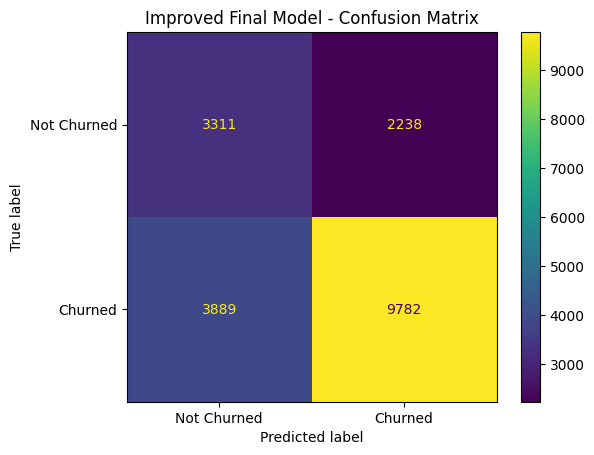

In [123]:
cm_final = confusion_matrix(
    y_test_final_v2,
    y_pred_final_v2
)

print("Confusion Matrix:")
print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Not Churned", "Churned"]
)

disp.plot()
plt.title("Improved Final Model - Confusion Matrix")
plt.show()

In [124]:
feature_importance_final = pd.DataFrame({
    "Feature": X_train_final_v2.columns,
    "Importance": final_rf_v2.feature_importances_
})

feature_importance_final = feature_importance_final.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_final)


,Feature,Importance
9,total_freight,0.617424
1,total_spend,0.079149
8,total_item_value,0.074442
2,avg_order_value,0.074324
10,avg_review_score,0.055284
3,avg_installments,0.035427
5,total_items,0.031510
7,unique_sellers,0.009718
6,unique_products,0.008893
11,total_reviews,0.007014


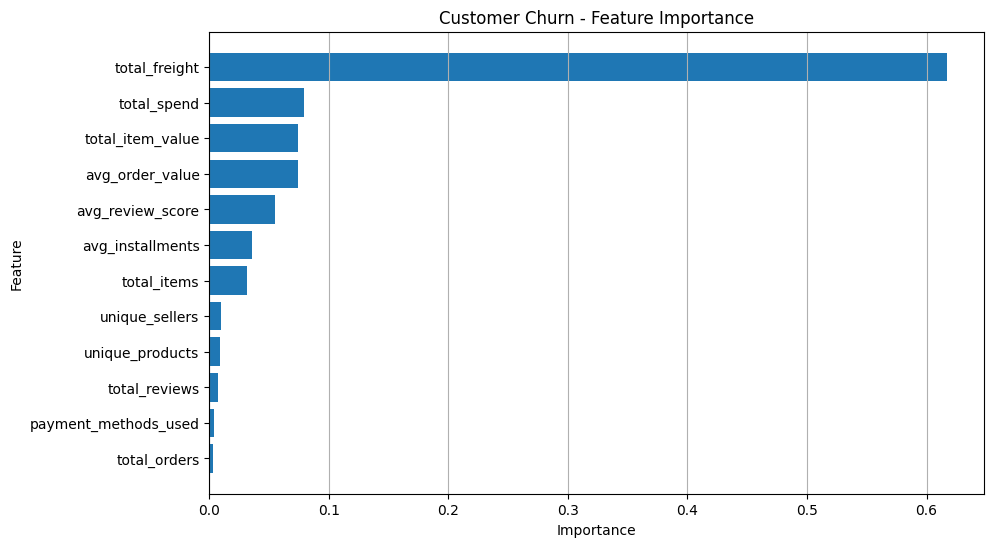

In [125]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_final["Feature"],
    feature_importance_final["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Customer Churn - Feature Importance")

plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [126]:
print("Top 5 features influencing churn:")

display(
    feature_importance_final.head(5)
)

Top 5 features influencing churn:


,Feature,Importance
9,total_freight,0.617424
1,total_spend,0.079149
8,total_item_value,0.074442
2,avg_order_value,0.074324
10,avg_review_score,0.055284


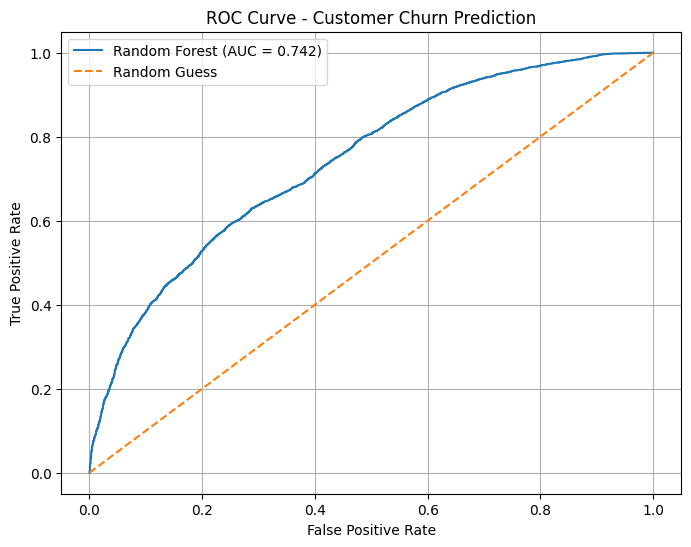

In [127]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test_final_v2,
    y_prob_final_v2
)

auc_score = roc_auc_score(
    y_test_final_v2,
    y_prob_final_v2
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid()

plt.show()

In [128]:
print("Final ROC-AUC:", round(auc_score, 4))

if auc_score >= 0.70:
    print("Model has good discrimination ability.")
elif auc_score >= 0.60:
    print("Model has moderate discrimination ability.")
else:
    print("Model needs improvement.")

Final ROC-AUC: 0.7421
Model has good discrimination ability.


In [129]:
print(
    classification_report(
        y_test_final_v2,
        y_pred_final_v2,
        target_names=["Not Churned", "Churned"],
        zero_division=0
    )
)

NameError: name 'classification_report' is not defined

In [130]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_final_v2,
        y_pred_final_v2,
        target_names=["Not Churned", "Churned"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Churned       0.46      0.60      0.52      5549
     Churned       0.81      0.72      0.76     13671

    accuracy                           0.68     19220
   macro avg       0.64      0.66      0.64     19220
weighted avg       0.71      0.68      0.69     19220



In [131]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

print("Models folder ready:", models_dir)

Models folder ready: ..\models


In [132]:
model_path = models_dir / "customer_churn_random_forest.pkl"

joblib.dump(
    final_rf_v2,
    model_path
)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: ..\models\customer_churn_random_forest.pkl


In [133]:
features_path = models_dir / "churn_features.pkl"

joblib.dump(
    final_ml_features,
    features_path
)

print("Feature list saved successfully!")
print("Location:", features_path)

Feature list saved successfully!
Location: ..\models\churn_features.pkl


In [134]:
loaded_model = joblib.load("../models/customer_churn_random_forest.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [135]:
test_predictions = loaded_model.predict(X_test_final_v2)

print("Prediction successful!")
print("Number of predictions:", len(test_predictions))

Prediction successful!
Number of predictions: 19220


In [136]:
loaded_features = joblib.load("../models/churn_features.pkl")

print("Saved features:")
print(loaded_features)

print("\nNumber of features:", len(loaded_features))

Saved features:
['total_orders', 'total_spend', 'avg_order_value', 'avg_installments', 'payment_methods_used', 'total_items', 'unique_products', 'unique_sellers', 'total_item_value', 'total_freight', 'avg_review_score', 'total_reviews']

Number of features: 12


In [137]:
from pathlib import Path

models_dir = Path("../models")

print("Model files:")
for file in models_dir.iterdir():
    print("✓", file.name)

Model files:
✓ churn_features.pkl
✓ customer_churn_random_forest.pkl


In [138]:
processed_dir = Path("../data/processed")

print("\nProcessed data files:")
for file in processed_dir.iterdir():
    print("✓", file.name)


Processed data files:
✓ business_action_summary.csv
✓ business_kpis.csv
✓ category_analysis.csv
✓ clean_orders_final.csv
✓ clean_orders_stage1.csv
✓ clean_orders_stage2.csv
✓ clean_orders_stage3.csv
✓ clean_orders_stage4.csv
✓ clean_orders_stage5.csv
✓ clean_orders_stage6.csv
✓ customer_decision_segments.csv
✓ customer_ml_dataset_v1.csv
✓ customer_ml_features_v1.csv
✓ customer_orders.csv
✓ customer_retention_base.csv
✓ customer_rfm_base.csv
✓ customer_segments.csv
✓ customer_summary.csv
✓ customer_summary_recency.csv
✓ customer_summary_rfm_base.csv
✓ monthly_revenue_analysis.csv
✓ order_level_dataset.csv
✓ segment_business_value.csv


In [139]:
print("========== STEP 4 FINAL SUMMARY ==========")

print("Model: Random Forest")
print("ROC-AUC:", round(roc_auc_score(y_test_final_v2, y_prob_final_v2), 4))
print("Accuracy:", round(accuracy_score(y_test_final_v2, y_pred_final_v2), 4))
print("Precision:", round(precision_score(y_test_final_v2, y_pred_final_v2), 4))
print("Recall:", round(recall_score(y_test_final_v2, y_pred_final_v2), 4))
print("F1 Score:", round(f1_score(y_test_final_v2, y_pred_final_v2), 4))

print("\nSTEP 4 COMPLETE!")

========== STEP 4 FINAL SUMMARY ==========
Model: Random Forest
ROC-AUC: 0.7421
Accuracy: 0.6812
Precision: 0.8138
Recall: 0.7155
F1 Score: 0.7615

STEP 4 COMPLETE!


In [140]:

customer_features["churn_probability"] = final_rf_v2.predict_proba(
    X_final_v2
)[:, 1]

display(
    customer_features[
        ["customer_unique_id", "churned", "churn_probability"]
    ].head()
)


,customer_unique_id,churned,churn_probability
0,0000366f3b9a7992bf8c76cfdf3221e2,0,0.492861
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,0.515647
2,0000f46a3911fa3c0805444483337064,1,0.721049
3,0000f6ccb0745a6a4b88665a16c9f078,1,0.664621
4,0004aac84e0df4da2b147fca70cf8255,1,0.620361


In [141]:
customer_features["churn_probability_pct"] = (
    customer_features["churn_probability"] * 100
).round(2)

display(
    customer_features[
        [
            "customer_unique_id",
            "churn_probability_pct"
        ]
    ].head(10)
)

,customer_unique_id,churn_probability_pct
0,0000366f3b9a7992bf8c76cfdf3221e2,49.29
1,0000b849f77a49e4a4ce2b2a4ca5be3f,51.56
2,0000f46a3911fa3c0805444483337064,72.10
3,0000f6ccb0745a6a4b88665a16c9f078,66.46
4,0004aac84e0df4da2b147fca70cf8255,62.04
5,0004bd2a26a76fe21f786e4fbd80607f,53.99
6,00050ab1314c0e55a6ca13cf7181fecf,24.02
7,00053a61a98854899e70ed204dd4bafe,56.08
8,0005e1862207bf6ccc02e4228effd9a0,59.29
9,0005ef4cd20d2893f0d9fbd94d3c0d97,56.46


In [142]:
high_risk_candidates = customer_features.sort_values(
    "churn_probability",
    ascending=False
)

display(
    high_risk_candidates[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "total_orders",
            "total_spend",
            "avg_review_score"
        ]
    ].head(10)
)

,customer_unique_id,churn_probability_pct,total_orders,total_spend,avg_review_score
17199,2da54b98229287d62e9416b22c7c701d,97.76,1,166.99,1.0
35794,5ef3d73ff5f2017d60ad9e87633f7143,97.76,1,171.61,1.0
48634,8141dd1e051afe7d72079570fe72d5f1,97.66,1,184.94,1.0
32371,55fbb57fd54c35a38c80c2a032a6ca6e,97.66,1,160.94,1.0
48791,81acf66173bb80d6988f3aa37d56176b,97.66,1,160.68,1.0
42616,7146a4a7f52aebbfe3a384100cd5c9d4,97.39,1,188.45,1.0
69892,b9efc86b7c6269eaeba5bdbdd5127e1b,97.16,1,147.99,1.0
6903,123ecbb4fb560cff85dd1072dd0a613d,96.79,1,221.84,1.0
88726,ec31ab57bc5e2588a118777ce93ebaf0,96.73,1,249.14,1.0
13488,23b8272c10c49458eac0b8626f0666ca,96.71,1,1643.64,1.0


In [143]:
customer_features["risk_segment"] = pd.cut(
    customer_features["churn_probability"],
    bins=[-float("inf"), 0.40, 0.70, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

display(
    customer_features[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "risk_segment"
        ]
    ].head(10)
)

,customer_unique_id,churn_probability_pct,risk_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,49.29,Medium Risk
1,0000b849f77a49e4a4ce2b2a4ca5be3f,51.56,Medium Risk
2,0000f46a3911fa3c0805444483337064,72.10,High Risk
3,0000f6ccb0745a6a4b88665a16c9f078,66.46,Medium Risk
4,0004aac84e0df4da2b147fca70cf8255,62.04,Medium Risk
5,0004bd2a26a76fe21f786e4fbd80607f,53.99,Medium Risk
6,00050ab1314c0e55a6ca13cf7181fecf,24.02,Low Risk
7,00053a61a98854899e70ed204dd4bafe,56.08,Medium Risk
8,0005e1862207bf6ccc02e4228effd9a0,59.29,Medium Risk
9,0005ef4cd20d2893f0d9fbd94d3c0d97,56.46,Medium Risk


In [144]:
risk_counts = customer_features["risk_segment"].value_counts()

print("Customer Risk Segments:")
print(risk_counts)

Customer Risk Segments:
risk_segment
Medium Risk    75797
Low Risk       13972
High Risk       6327
Name: count, dtype: int64


In [145]:
risk_percentages = (
    customer_features["risk_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Risk Segment Percentages:")
print(risk_percentages)

Risk Segment Percentages:
risk_segment
Medium Risk    78.88
Low Risk       14.54
High Risk       6.58
Name: proportion, dtype: float64


In [146]:
high_risk_customers = customer_features[
    customer_features["risk_segment"] == "High Risk"
].copy()

print("High-risk customers:", len(high_risk_customers))

display(
    high_risk_customers[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "total_orders",
            "total_spend",
            "avg_order_value",
            "avg_review_score"
        ]
    ].head(10)
)

High-risk customers: 6327


,customer_unique_id,churn_probability_pct,total_orders,total_spend,avg_order_value,avg_review_score
2,0000f46a3911fa3c0805444483337064,72.10,1,86.22,86.22,3.0
10,0006fdc98a402fceb4eb0ee528f6a8d4,74.05,1,29.00,29.00,3.0
23,0010a452c6d13139e50b57f19f52e04e,71.73,1,325.93,325.93,1.0
38,00196fdb2bf9edfc35e88ebfbcf8d781,74.35,1,27.00,27.00,3.0
44,001ae44fa04911a9e9577356dce6c63c,73.45,1,116.23,116.23,0.0
50,0023557a94bef0038066b5d1b3dc763e,70.70,1,107.44,107.44,3.0
63,002cdf87d4c03f08f7eb4551a923affc,72.17,1,228.67,228.67,1.0
70,002feefec5af0a3b26ee7839c66d205e,75.88,1,77.57,77.57,1.0
80,003650b504826ea534e02eba0ab58dd5,79.28,1,21.77,21.77,4.0
169,006bbb235068a01d2e3e47fa09ccf53c,70.17,1,34.00,34.00,5.0


In [147]:
high_value_risk = high_risk_customers.sort_values(
    ["total_spend", "churn_probability"],
    ascending=[False, False]
)

display(
    high_value_risk[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "total_spend",
            "total_orders",
            "avg_order_value",
            "avg_review_score"
        ]
    ].head(20)
)

,customer_unique_id,churn_probability_pct,total_spend,total_orders,avg_order_value,avg_review_score
69948,ba0fed3e80432a2a1679d58a24732c93,91.42,2125.19,1,2125.19,1.0
4650,0c3dbe243398d9af58ac1a6d27cbe004,91.77,2116.01,1,2116.01,1.0
54810,921d58c81068176026975777ae295c05,86.87,2039.44,1,2039.44,1.0
13488,23b8272c10c49458eac0b8626f0666ca,96.71,1643.64,1,1643.64,1.0
23146,3d7bc770cfdbe423eb80de6893a8e05e,90.51,1631.94,1,1631.94,3.0
43136,72994e988788873a1df6dad43d38a2bd,96.71,1620.77,1,1620.77,1.0
67398,b339a1ec295defef7cd27439c8718066,96.51,1528.99,1,1528.99,1.0
1735,04a46c134f7f3d15f7f4a20afbbd915f,89.11,1528.99,1,1528.99,1.0
64334,ab14aff32b9c7c55378170003a076665,96.31,1520.77,1,1520.77,1.0
51092,87ff69ee0a94361f61fbd5e5699c5230,89.17,1520.77,1,1520.77,5.0


In [148]:
spend_threshold = customer_features["total_spend"].quantile(0.75)

print("High-value spending threshold:", round(spend_threshold, 2))

High-value spending threshold: 183.53


In [149]:
def assign_priority(row):
    if row["risk_segment"] == "High Risk" and row["total_spend"] >= spend_threshold:
        return "Critical Priority"
    elif row["risk_segment"] == "High Risk":
        return "High Priority"
    elif row["risk_segment"] == "Medium Risk":
        return "Medium Priority"
    else:
        return "Low Priority"


customer_features["priority"] = customer_features.apply(
    assign_priority,
    axis=1
)

display(
    customer_features[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "risk_segment",
            "total_spend",
            "priority"
        ]
    ].head(10)
)

,customer_unique_id,churn_probability_pct,risk_segment,total_spend,priority
0,0000366f3b9a7992bf8c76cfdf3221e2,49.29,Medium Risk,141.90,Medium Priority
1,0000b849f77a49e4a4ce2b2a4ca5be3f,51.56,Medium Risk,27.19,Medium Priority
2,0000f46a3911fa3c0805444483337064,72.10,High Risk,86.22,High Priority
3,0000f6ccb0745a6a4b88665a16c9f078,66.46,Medium Risk,43.62,Medium Priority
4,0004aac84e0df4da2b147fca70cf8255,62.04,Medium Risk,196.89,Medium Priority
5,0004bd2a26a76fe21f786e4fbd80607f,53.99,Medium Risk,166.98,Medium Priority
6,00050ab1314c0e55a6ca13cf7181fecf,24.02,Low Risk,35.38,Low Priority
7,00053a61a98854899e70ed204dd4bafe,56.08,Medium Risk,419.18,Medium Priority
8,0005e1862207bf6ccc02e4228effd9a0,59.29,Medium Risk,150.12,Medium Priority
9,0005ef4cd20d2893f0d9fbd94d3c0d97,56.46,Medium Risk,129.76,Medium Priority


In [150]:
priority_counts = customer_features["priority"].value_counts()

print("Customer Priority Distribution:")
print(priority_counts)

Customer Priority Distribution:
priority
Medium Priority      75797
Low Priority         13972
High Priority         5523
Critical Priority      804
Name: count, dtype: int64


In [151]:
def recommend_action(priority):
    if priority == "Critical Priority":
        return "Personalized offer + priority support"
    elif priority == "High Priority":
        return "Targeted discount + re-engagement campaign"
    elif priority == "Medium Priority":
        return "Personalized email + product recommendations"
    else:
        return "Regular engagement + loyalty program"


customer_features["recommended_action"] = (
    customer_features["priority"]
    .apply(recommend_action)
)

display(
    customer_features[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "total_spend",
            "priority",
            "recommended_action"
        ]
    ].head(20)
)

,customer_unique_id,churn_probability_pct,total_spend,priority,recommended_action
0,0000366f3b9a7992bf8c76cfdf3221e2,49.29,141.90,Medium Priority,Personalized email + product recommendations
1,0000b849f77a49e4a4ce2b2a4ca5be3f,51.56,27.19,Medium Priority,Personalized email + product recommendations
2,0000f46a3911fa3c0805444483337064,72.10,86.22,High Priority,Targeted discount + re-engagement campaign
3,0000f6ccb0745a6a4b88665a16c9f078,66.46,43.62,Medium Priority,Personalized email + product recommendations
4,0004aac84e0df4da2b147fca70cf8255,62.04,196.89,Medium Priority,Personalized email + product recommendations
5,0004bd2a26a76fe21f786e4fbd80607f,53.99,166.98,Medium Priority,Personalized email + product recommendations
6,00050ab1314c0e55a6ca13cf7181fecf,24.02,35.38,Low Priority,Regular engagement + loyalty program
7,00053a61a98854899e70ed204dd4bafe,56.08,419.18,Medium Priority,Personalized email + product recommendations
8,0005e1862207bf6ccc02e4228effd9a0,59.29,150.12,Medium Priority,Personalized email + product recommendations
9,0005ef4cd20d2893f0d9fbd94d3c0d97,56.46,129.76,Medium Priority,Personalized email + product recommendations


In [152]:
action_summary = (
    customer_features["recommended_action"]
    .value_counts()
)

print("Recommended Retention Actions:")
print(action_summary)

Recommended Retention Actions:
recommended_action
Personalized email + product recommendations    75797
Regular engagement + loyalty program            13972
Targeted discount + re-engagement campaign       5523
Personalized offer + priority support             804
Name: count, dtype: int64


In [153]:
critical_customers = customer_features[
    customer_features["priority"] == "Critical Priority"
].sort_values(
    "churn_probability",
    ascending=False
)

display(
    critical_customers[
        [
            "customer_unique_id",
            "churn_probability_pct",
            "total_spend",
            "total_orders",
            "avg_order_value",
            "avg_review_score",
            "priority",
            "recommended_action"
        ]
    ].head(20)
)

,customer_unique_id,churn_probability_pct,total_spend,total_orders,avg_order_value,avg_review_score,priority,recommended_action
48634,8141dd1e051afe7d72079570fe72d5f1,97.66,184.94,1,184.94,1.0,Critical Priority,Personalized offer + priority support
42616,7146a4a7f52aebbfe3a384100cd5c9d4,97.39,188.45,1,188.45,1.0,Critical Priority,Personalized offer + priority support
6903,123ecbb4fb560cff85dd1072dd0a613d,96.79,221.84,1,221.84,1.0,Critical Priority,Personalized offer + priority support
88726,ec31ab57bc5e2588a118777ce93ebaf0,96.73,249.14,1,249.14,1.0,Critical Priority,Personalized offer + priority support
43136,72994e988788873a1df6dad43d38a2bd,96.71,1620.77,1,1620.77,1.0,Critical Priority,Personalized offer + priority support
13488,23b8272c10c49458eac0b8626f0666ca,96.71,1643.64,1,1643.64,1.0,Critical Priority,Personalized offer + priority support
67398,b339a1ec295defef7cd27439c8718066,96.51,1528.99,1,1528.99,1.0,Critical Priority,Personalized offer + priority support
64334,ab14aff32b9c7c55378170003a076665,96.31,1520.77,1,1520.77,1.0,Critical Priority,Personalized offer + priority support
87800,e9bd60258117342273c84198e732b955,96.12,192.77,1,192.77,1.0,Critical Priority,Personalized offer + priority support
75492,c8d832b1e6f4aa662d0fefabfca04265,96.11,1384.73,1,1384.73,1.0,Critical Priority,Personalized offer + priority support


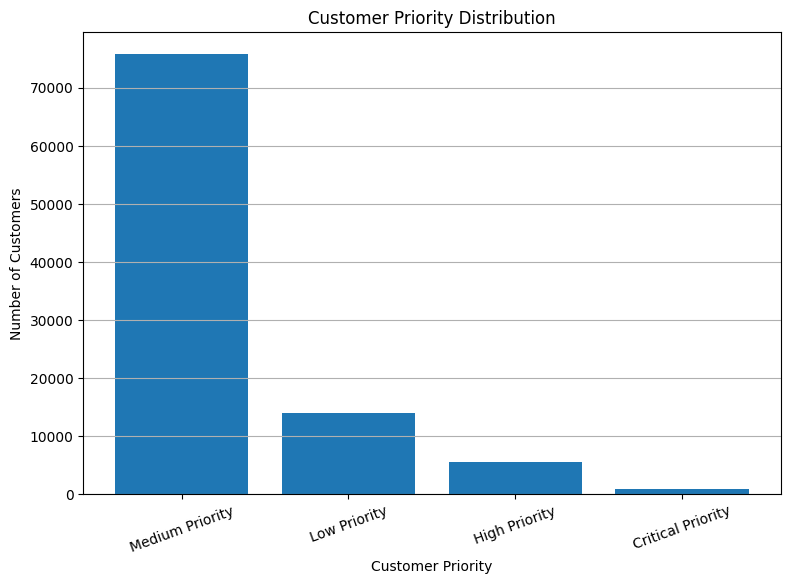

In [154]:
import matplotlib.pyplot as plt

priority_counts = customer_features["priority"].value_counts()

plt.figure(figsize=(9, 6))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.xlabel("Customer Priority")
plt.ylabel("Number of Customers")
plt.title("Customer Priority Distribution")
plt.xticks(rotation=20)

plt.grid(axis="y")
plt.show()

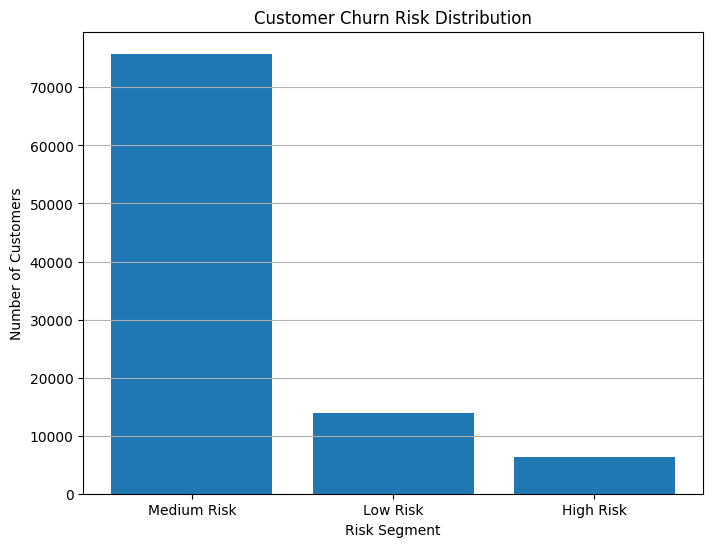

In [155]:
risk_counts = customer_features["risk_segment"].value_counts()

plt.figure(figsize=(8, 6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

plt.grid(axis="y")
plt.show()

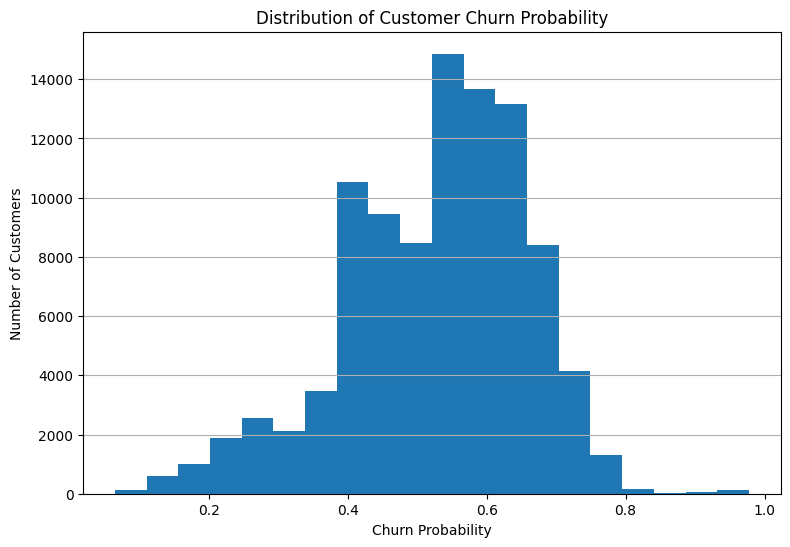

In [156]:
plt.figure(figsize=(9, 6))

plt.hist(
    customer_features["churn_probability"],
    bins=20
)

plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Churn Probability")

plt.grid(axis="y")
plt.show()

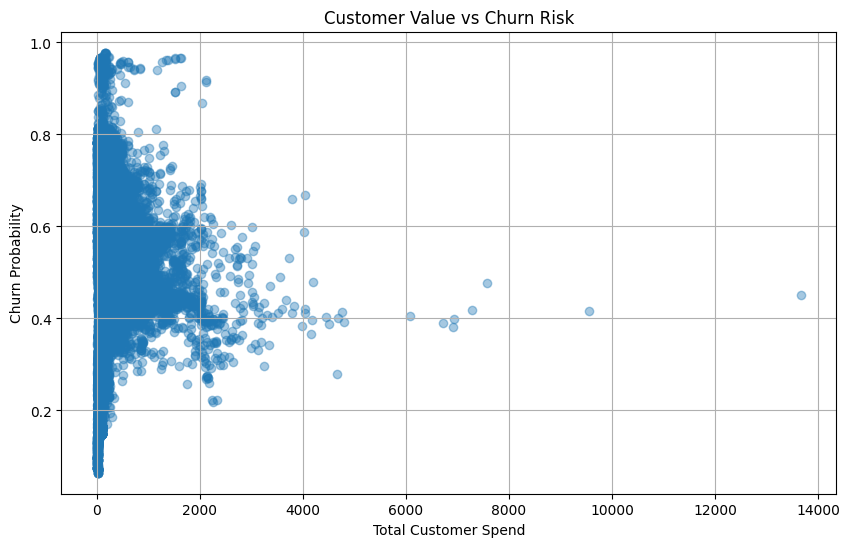

In [157]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_features["total_spend"],
    customer_features["churn_probability"],
    alpha=0.4
)

plt.xlabel("Total Customer Spend")
plt.ylabel("Churn Probability")
plt.title("Customer Value vs Churn Risk")
plt.grid()

plt.show()

In [158]:
risk_value_summary = (
    customer_features
    .groupby("risk_segment", observed=True)
    .agg(
        customers=("customer_unique_id", "count"),
        average_spend=("total_spend", "mean"),
        total_revenue=("total_spend", "sum"),
        average_churn_probability=("churn_probability", "mean")
    )
    .round(2)
)

display(risk_value_summary)

,customers,average_spend,total_revenue,average_churn_probability
risk_segment,,,,
Low Risk,13972,137.87,1926281.94,0.30
Medium Risk,75797,177.34,13441876.63,0.55
High Risk,6327,101.27,640713.55,0.74


In [159]:
critical_value_summary = (
    customer_features[
        customer_features["priority"] == "Critical Priority"
    ]
    .sort_values("total_spend", ascending=False)
)

display(
    critical_value_summary[
        [
            "customer_unique_id",
            "total_spend",
            "total_orders",
            "churn_probability_pct",
            "priority",
            "recommended_action"
        ]
    ].head(20)
)

,customer_unique_id,total_spend,total_orders,churn_probability_pct,priority,recommended_action
69948,ba0fed3e80432a2a1679d58a24732c93,2125.19,1,91.42,Critical Priority,Personalized offer + priority support
4650,0c3dbe243398d9af58ac1a6d27cbe004,2116.01,1,91.77,Critical Priority,Personalized offer + priority support
54810,921d58c81068176026975777ae295c05,2039.44,1,86.87,Critical Priority,Personalized offer + priority support
13488,23b8272c10c49458eac0b8626f0666ca,1643.64,1,96.71,Critical Priority,Personalized offer + priority support
23146,3d7bc770cfdbe423eb80de6893a8e05e,1631.94,1,90.51,Critical Priority,Personalized offer + priority support
43136,72994e988788873a1df6dad43d38a2bd,1620.77,1,96.71,Critical Priority,Personalized offer + priority support
1735,04a46c134f7f3d15f7f4a20afbbd915f,1528.99,1,89.11,Critical Priority,Personalized offer + priority support
67398,b339a1ec295defef7cd27439c8718066,1528.99,1,96.51,Critical Priority,Personalized offer + priority support
64334,ab14aff32b9c7c55378170003a076665,1520.77,1,96.31,Critical Priority,Personalized offer + priority support
51092,87ff69ee0a94361f61fbd5e5699c5230,1520.77,1,89.17,Critical Priority,Personalized offer + priority support


In [160]:
high_risk_revenue = customer_features.loc[
    customer_features["risk_segment"] == "High Risk",
    "total_spend"
].sum()

critical_revenue = customer_features.loc[
    customer_features["priority"] == "Critical Priority",
    "total_spend"
].sum()

total_customer_revenue = customer_features["total_spend"].sum()

print("Total customer revenue:", round(total_customer_revenue, 2))
print("High-risk customer revenue:", round(high_risk_revenue, 2))
print("Critical customer revenue:", round(critical_revenue, 2))

Total customer revenue: 16008872.12
High-risk customer revenue: 640713.55
Critical customer revenue: 289815.5


In [161]:
high_risk_revenue_pct = (
    high_risk_revenue / total_customer_revenue * 100
)

critical_revenue_pct = (
    critical_revenue / total_customer_revenue * 100
)

print(
    "High-risk revenue percentage:",
    round(high_risk_revenue_pct, 2),
    "%"
)

print(
    "Critical revenue percentage:",
    round(critical_revenue_pct, 2),
    "%"
)

High-risk revenue percentage: 4.0 %
Critical revenue percentage: 1.81 %


In [162]:
revenue_risk_summary = pd.DataFrame({
    "Metric": [
        "Total Customer Revenue",
        "High-Risk Customer Revenue",
        "Critical Customer Revenue"
    ],
    "Value": [
        total_customer_revenue,
        high_risk_revenue,
        critical_revenue
    ]
})

display(revenue_risk_summary)

,Metric,Value
0,Total Customer Revenue,16008872.12
1,High-Risk Customer Revenue,640713.55
2,Critical Customer Revenue,289815.50


In [163]:
retention_rates = [0.20, 0.40, 0.60]

scenario_results = []

for rate in retention_rates:
    scenario_results.append({
        "Retention Rate": f"{rate*100:.0f}%",
        "High-Risk Revenue Saved": round(high_risk_revenue * rate, 2),
        "Critical Revenue Saved": round(critical_revenue * rate, 2)
    })

retention_scenarios = pd.DataFrame(scenario_results)

display(retention_scenarios)

,Retention Rate,High-Risk Revenue Saved,Critical Revenue Saved
0,20%,128142.71,57963.1
1,40%,256285.42,115926.2
2,60%,384428.13,173889.3


In [164]:
retention_scenarios["High-Risk Revenue Saved %"] = (
    retention_scenarios["High-Risk Revenue Saved"]
    / total_customer_revenue * 100
).round(2)

display(retention_scenarios)

,Retention Rate,High-Risk Revenue Saved,Critical Revenue Saved,High-Risk Revenue Saved %
0,20%,128142.71,57963.1,0.8
1,40%,256285.42,115926.2,1.6
2,60%,384428.13,173889.3,2.4


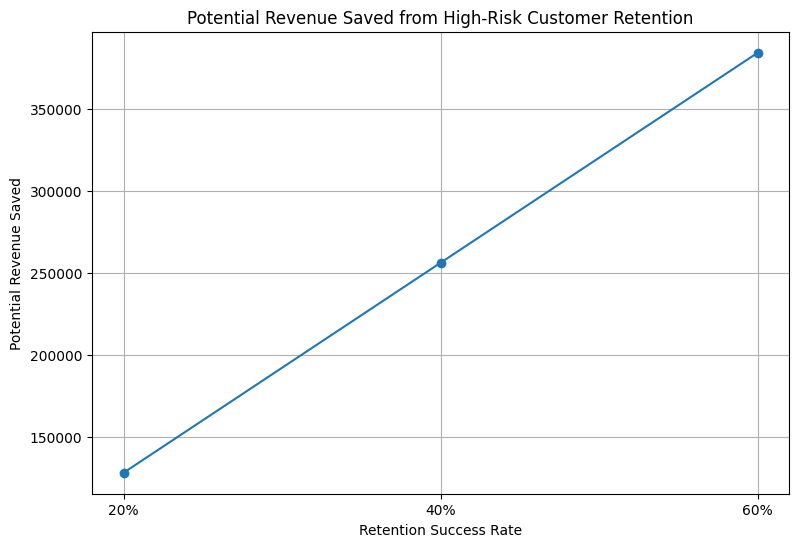

In [165]:
plt.figure(figsize=(9, 6))

plt.plot(
    retention_scenarios["Retention Rate"],
    retention_scenarios["High-Risk Revenue Saved"],
    marker="o"
)

plt.xlabel("Retention Success Rate")
plt.ylabel("Potential Revenue Saved")
plt.title("Potential Revenue Saved from High-Risk Customer Retention")
plt.grid()

plt.show()

In [166]:
decision_table = customer_features[
    [
        "customer_unique_id",
        "total_orders",
        "total_spend",
        "avg_order_value",
        "avg_review_score",
        "churn_probability",
        "churn_probability_pct",
        "risk_segment",
        "priority",
        "recommended_action"
    ]
].copy()

display(decision_table.head(10))

,customer_unique_id,total_orders,total_spend,avg_order_value,avg_review_score,churn_probability,churn_probability_pct,risk_segment,priority,recommended_action
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,0.492861,49.29,Medium Risk,Medium Priority,Personalized email + product recommendations
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,0.515647,51.56,Medium Risk,Medium Priority,Personalized email + product recommendations
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,0.721049,72.10,High Risk,High Priority,Targeted discount + re-engagement campaign
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,0.664621,66.46,Medium Risk,Medium Priority,Personalized email + product recommendations
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,0.620361,62.04,Medium Risk,Medium Priority,Personalized email + product recommendations
5,0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98,4.0,0.539897,53.99,Medium Risk,Medium Priority,Personalized email + product recommendations
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38,4.0,0.240230,24.02,Low Risk,Low Priority,Regular engagement + loyalty program
7,00053a61a98854899e70ed204dd4bafe,1,419.18,419.18,1.0,0.560773,56.08,Medium Risk,Medium Priority,Personalized email + product recommendations
8,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,4.0,0.592900,59.29,Medium Risk,Medium Priority,Personalized email + product recommendations
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,1.0,0.564610,56.46,Medium Risk,Medium Priority,Personalized email + product recommendations


In [167]:
priority_order = {
    "Critical Priority": 1,
    "High Priority": 2,
    "Medium Priority": 3,
    "Low Priority": 4
}

decision_table["priority_rank"] = (
    decision_table["priority"].map(priority_order)
)

decision_table = decision_table.sort_values(
    ["priority_rank", "churn_probability"],
    ascending=[True, False]
).drop(columns="priority_rank")

display(decision_table.head(20))

,customer_unique_id,total_orders,total_spend,avg_order_value,avg_review_score,churn_probability,churn_probability_pct,risk_segment,priority,recommended_action
48634,8141dd1e051afe7d72079570fe72d5f1,1,184.94,184.94,1.0,0.976643,97.66,High Risk,Critical Priority,Personalized offer + priority support
42616,7146a4a7f52aebbfe3a384100cd5c9d4,1,188.45,188.45,1.0,0.973875,97.39,High Risk,Critical Priority,Personalized offer + priority support
6903,123ecbb4fb560cff85dd1072dd0a613d,1,221.84,221.84,1.0,0.967907,96.79,High Risk,Critical Priority,Personalized offer + priority support
88726,ec31ab57bc5e2588a118777ce93ebaf0,1,249.14,249.14,1.0,0.967309,96.73,High Risk,Critical Priority,Personalized offer + priority support
13488,23b8272c10c49458eac0b8626f0666ca,1,1643.64,1643.64,1.0,0.967102,96.71,High Risk,Critical Priority,Personalized offer + priority support
43136,72994e988788873a1df6dad43d38a2bd,1,1620.77,1620.77,1.0,0.967102,96.71,High Risk,Critical Priority,Personalized offer + priority support
67398,b339a1ec295defef7cd27439c8718066,1,1528.99,1528.99,1.0,0.965102,96.51,High Risk,Critical Priority,Personalized offer + priority support
64334,ab14aff32b9c7c55378170003a076665,1,1520.77,1520.77,1.0,0.963102,96.31,High Risk,Critical Priority,Personalized offer + priority support
87800,e9bd60258117342273c84198e732b955,1,192.77,192.77,1.0,0.961188,96.12,High Risk,Critical Priority,Personalized offer + priority support
14334,2615f18f801b0156237b068570d64217,1,1354.80,1354.80,1.0,0.961102,96.11,High Risk,Critical Priority,Personalized offer + priority support


In [168]:
print("Final Decision Intelligence Table")
print("Rows:", decision_table.shape[0])
print("Columns:", decision_table.shape[1])

print("\nColumns:")
print(decision_table.columns.tolist())

Final Decision Intelligence Table
Rows: 96096
Columns: 10

Columns:
['customer_unique_id', 'total_orders', 'total_spend', 'avg_order_value', 'avg_review_score', 'churn_probability', 'churn_probability_pct', 'risk_segment', 'priority', 'recommended_action']


In [169]:
decision_path = Path("../data/processed/customer_decision_table.csv")

decision_table.to_csv(
    decision_path,
    index=False
)

print("Decision table saved successfully!")
print("Location:", decision_path)

Decision table saved successfully!
Location: ..\data\processed\customer_decision_table.csv


In [170]:
print("File exists:", decision_path.exists())
print("File size:", round(decision_path.stat().st_size / 1024, 2), "KB")

File exists: True
File size: 13952.47 KB


In [171]:
decision_check = pd.read_csv(decision_path)

print("Loaded successfully!")
print("Shape:", decision_check.shape)

display(decision_check.head())

Loaded successfully!
Shape: (96096, 10)


,customer_unique_id,total_orders,total_spend,avg_order_value,avg_review_score,churn_probability,churn_probability_pct,risk_segment,priority,recommended_action
0,8141dd1e051afe7d72079570fe72d5f1,1,184.94,184.94,1.0,0.976643,97.66,High Risk,Critical Priority,Personalized offer + priority support
1,7146a4a7f52aebbfe3a384100cd5c9d4,1,188.45,188.45,1.0,0.973875,97.39,High Risk,Critical Priority,Personalized offer + priority support
2,123ecbb4fb560cff85dd1072dd0a613d,1,221.84,221.84,1.0,0.967907,96.79,High Risk,Critical Priority,Personalized offer + priority support
3,ec31ab57bc5e2588a118777ce93ebaf0,1,249.14,249.14,1.0,0.967309,96.73,High Risk,Critical Priority,Personalized offer + priority support
4,23b8272c10c49458eac0b8626f0666ca,1,1643.64,1643.64,1.0,0.967102,96.71,High Risk,Critical Priority,Personalized offer + priority support


In [172]:
management_summary = {
    "Total Customers": len(customer_features),
    "High Risk Customers": (
        customer_features["risk_segment"] == "High Risk"
    ).sum(),
    "Critical Priority Customers": (
        customer_features["priority"] == "Critical Priority"
    ).sum(),
    "Total Customer Revenue": round(total_customer_revenue, 2),
    "High Risk Revenue": round(high_risk_revenue, 2),
    "Critical Revenue": round(critical_revenue, 2),
    "High Risk Revenue %": round(high_risk_revenue_pct, 2),
    "Critical Revenue %": round(critical_revenue_pct, 2),
    "Model ROC-AUC": round(
        roc_auc_score(y_test_final_v2, y_prob_final_v2),
        4
    )
}

management_summary_df = pd.DataFrame(
    management_summary.items(),
    columns=["Metric", "Value"]
)

display(management_summary_df)

,Metric,Value
0,Total Customers,9.609600e+04
1,High Risk Customers,6.327000e+03
2,Critical Priority Customers,8.040000e+02
3,Total Customer Revenue,1.600887e+07
4,High Risk Revenue,6.407136e+05
5,Critical Revenue,2.898155e+05
6,High Risk Revenue %,4.000000e+00
7,Critical Revenue %,1.810000e+00
8,Model ROC-AUC,7.421000e-01


In [173]:
management_priority = (
    customer_features
    .groupby("priority", as_index=False)
    .agg(
        customers=("customer_unique_id", "count"),
        total_spend=("total_spend", "sum"),
        average_churn_probability=("churn_probability", "mean")
    )
)

management_priority["average_churn_probability"] = (
    management_priority["average_churn_probability"] * 100
).round(2)

management_priority["total_spend"] = (
    management_priority["total_spend"].round(2)
)

display(management_priority)

,priority,customers,total_spend,average_churn_probability
0,Critical Priority,804,289815.50,75.24
1,High Priority,5523,350898.05,73.67
2,Low Priority,13972,1926281.94,30.06
3,Medium Priority,75797,13441876.63,55.12


In [174]:
summary_path = Path(
    "../data/processed/management_summary.csv"
)

management_summary_df.to_csv(
    summary_path,
    index=False
)

print("Management summary saved!")
print("Location:", summary_path)

Management summary saved!
Location: ..\data\processed\management_summary.csv


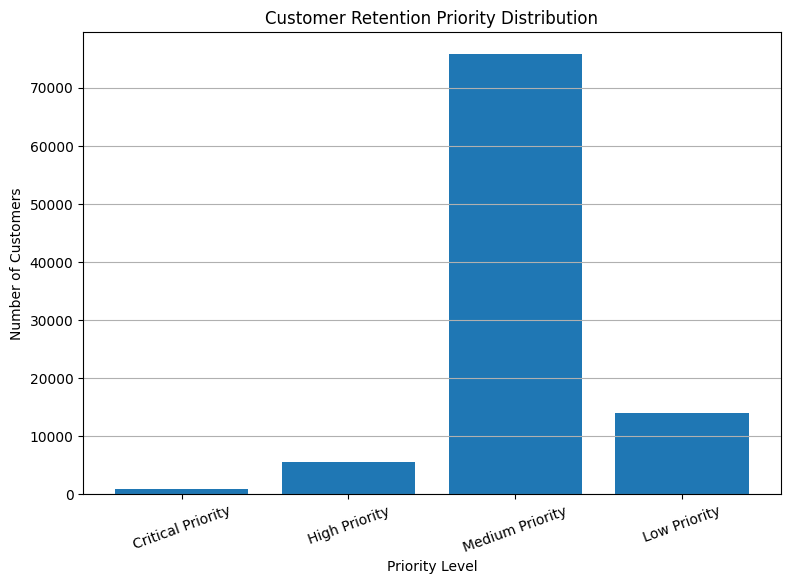

In [175]:
plt.figure(figsize=(9, 6))

priority_order = [
    "Critical Priority",
    "High Priority",
    "Medium Priority",
    "Low Priority"
]

priority_plot = (
    customer_features["priority"]
    .value_counts()
    .reindex(priority_order)
)

plt.bar(
    priority_plot.index,
    priority_plot.values
)

plt.xlabel("Priority Level")
plt.ylabel("Number of Customers")
plt.title("Customer Retention Priority Distribution")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

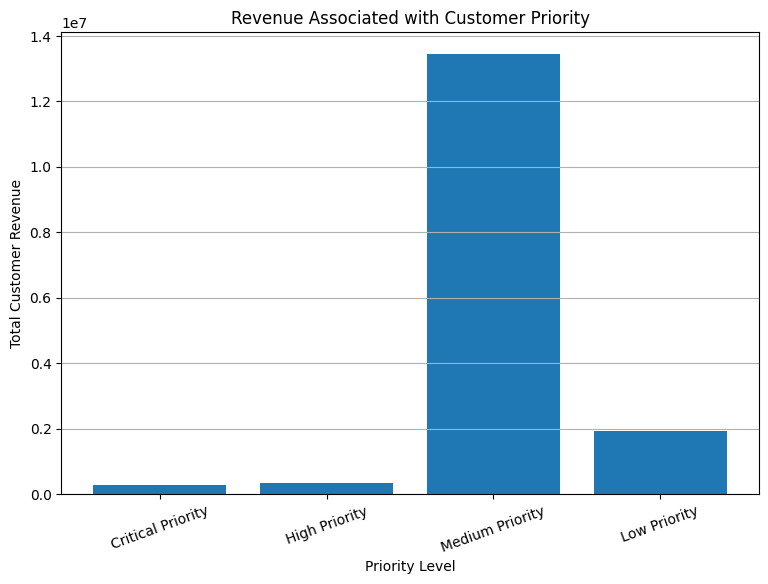

In [176]:
revenue_by_priority = (
    customer_features
    .groupby("priority", observed=True)["total_spend"]
    .sum()
    .reindex(priority_order)
)

plt.figure(figsize=(9, 6))

plt.bar(
    revenue_by_priority.index,
    revenue_by_priority.values
)

plt.xlabel("Priority Level")
plt.ylabel("Total Customer Revenue")
plt.title("Revenue Associated with Customer Priority")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

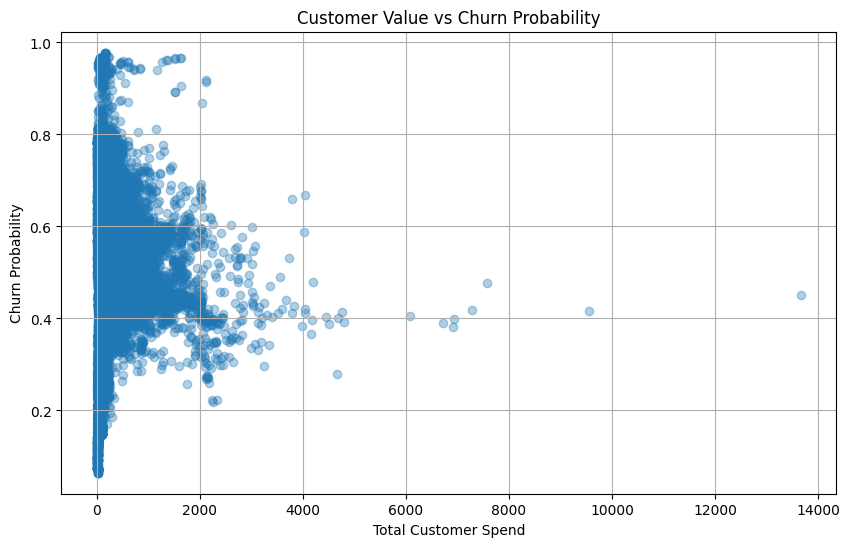

In [177]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_features["total_spend"],
    customer_features["churn_probability"],
    alpha=0.35
)

plt.xlabel("Total Customer Spend")
plt.ylabel("Churn Probability")
plt.title("Customer Value vs Churn Probability")
plt.grid()

plt.show()

In [178]:
dashboard_path = Path("../data/processed/dashboard_customer_data.csv")

decision_table.to_csv(
    dashboard_path,
    index=False
)

print("Dashboard data saved successfully!")
print("Location:", dashboard_path)

Dashboard data saved successfully!
Location: ..\data\processed\dashboard_customer_data.csv


In [179]:
priority_summary_path = Path(
    "../data/processed/priority_summary.csv"
)

management_priority.to_csv(
    priority_summary_path,
    index=False
)

print("Priority summary saved successfully!")
print("Location:", priority_summary_path)

Priority summary saved successfully!
Location: ..\data\processed\priority_summary.csv


In [180]:
output_files = [
    "../data/processed/customer_decision_table.csv",
    "../data/processed/management_summary.csv",
    "../data/processed/dashboard_customer_data.csv",
    "../data/processed/priority_summary.csv"
]

print("========== STEP 5 OUTPUT FILES ==========")

for file in output_files:
    path = Path(file)
    print(
        "✓" if path.exists() else "✗",
        path.name
    )

========== STEP 5 OUTPUT FILES ==========
✓ customer_decision_table.csv
✓ management_summary.csv
✓ dashboard_customer_data.csv
✓ priority_summary.csv


In [181]:
print("========== STEP 5 FINAL SUMMARY ==========")

print("Total Customers:", len(customer_features))

print(
    "Critical Priority:",
    (customer_features["priority"] == "Critical Priority").sum()
)

print(
    "High Priority:",
    (customer_features["priority"] == "High Priority").sum()
)

print(
    "Medium Priority:",
    (customer_features["priority"] == "Medium Priority").sum()
)

print(
    "Low Priority:",
    (customer_features["priority"] == "Low Priority").sum()
)

print("\nTotal Customer Revenue:", round(total_customer_revenue, 2))
print("High-Risk Revenue:", round(high_risk_revenue, 2))
print("Critical Revenue:", round(critical_revenue, 2))

print("\nModel ROC-AUC:", round(
    roc_auc_score(y_test_final_v2, y_prob_final_v2), 4
))

========== STEP 5 FINAL SUMMARY ==========
Total Customers: 96096
Critical Priority: 804
High Priority: 5523
Medium Priority: 75797
Low Priority: 13972

Total Customer Revenue: 16008872.12
High-Risk Revenue: 640713.55
Critical Revenue: 289815.5

Model ROC-AUC: 0.7421


In [182]:
print("\n========== PIPELINE CHECK ==========")

checks = {
    "Churn model available": final_rf_v2 is not None,
    "Churn probabilities available": "churn_probability" in customer_features.columns,
    "Risk segments available": "risk_segment" in customer_features.columns,
    "Priority levels available": "priority" in customer_features.columns,
    "Retention actions available": "recommended_action" in customer_features.columns,
    "Decision table available": len(decision_table) > 0
}

for check, result in checks.items():
    print("✓" if result else "✗", check)

if all(checks.values()):
    print("\n🎉 STEP 5 COMPLETE!")
else:
    print("\n⚠️ One or more checks failed.")


========== PIPELINE CHECK ==========
✓ Churn model available
✓ Churn probabilities available
✓ Risk segments available
✓ Priority levels available
✓ Retention actions available
✓ Decision table available

🎉 STEP 5 COMPLETE!
